# Pinguini di Palmer — Modelli Statistici
### Proyecto final · UFS-06/07

---

El dataset **Palmer Penguins** contiene medidas morfológicas de **333 pingüinos**
de tres especies del archipiélago de Palmer, Antártida.

| Variable | Tipo | Descripción |
|----------|------|-------------|
| `bill_length_mm` | continua | Longitud del pico (mm) |
| `bill_depth_mm` | continua | Profundidad del pico (mm) |
| `flipper_length_mm` | continua | Longitud del ala (mm) |
| `body_mass_g` | continua | Masa corporal (g) |
| `species` | categórica | Adélie · Chinstrap · Gentoo |
| `island` | categórica | Biscoe · Dream · Torgersen |

---

### Estructura del proyecto

| # | Pregunta | Herramienta |
|---|---------|-------------|
| 1 | ¿Quiénes son los pingüinos de Palmer? | EDA, estadísticas descriptivas |
| 2 | ¿Podemos asumir normalidad en los datos? | Shapiro-Wilk, Q-Q plot |
| 3 | ¿Cuánto pesa realmente un pingüino Gentoo? | IC 95%, t-Student |
| 4 | ¿Cada especie tiene su isla? | Chi-cuadrado |
| 5 | ¿La isla donde viven afecta el peso de los Adélie? | ANOVA, Levene, Tukey HSD |
| 6 | ¿El pico delata la especie? Paradoja de Simpson | Correlación de Pearson |
| 8 | ¿Se puede saber de qué isla viene un pingüino solo mirándolo? | Regresión logística |

---
## 0. Configuración

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import shapiro, levene, f_oneway, chi2_contingency, ttest_ind
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, roc_auc_score, ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

In [32]:
# ── Paleta única para todos los gráficos ─────────────────────────────────────
# Tres colores neutros para las especies — distinguibles en color y en escala de grises
COLORS = {
    "Adelie"   : "#4C72B0",   # azul pizarra
    "Chinstrap": "#C44E52",   # terracota
    "Gentoo"   : "#55A868",   # verde salvia
}
SPECIES_ORDER = ["Adelie", "Chinstrap", "Gentoo"]

# Colores auxiliares — usados en barras de IC, líneas de referencia, etc.
C_DARK  = "#2C2C2A"   # casi negro — líneas de IC, ejes
C_MID   = "#888780"   # gris medio — puntos secundarios, grilla
C_LIGHT = "#F1EFE8"   # gris claro — fondos de figuras

# Nivel de significancia global
ALPHA = 0.05

# Variables morfológicas continuas
MORPH = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]

# Estilo gráfico global
plt.rcParams.update({
    "figure.facecolor" : C_LIGHT,
    "axes.facecolor"   : "white",
    "axes.edgecolor"   : C_MID,
    "axes.labelcolor"  : C_DARK,
    "axes.titlecolor"  : C_DARK,
    "axes.titlesize"   : 11,
    "axes.labelsize"   : 10,
    "axes.grid"        : True,
    "grid.color"       : "#D3D1C7",
    "grid.alpha"       : 0.5,
    "grid.linewidth"   : 0.6,
    "xtick.color"      : C_MID,
    "ytick.color"      : C_MID,
    "text.color"       : C_DARK,
    "legend.framealpha": 0.92,
    "legend.edgecolor" : "#D3D1C7",
    "figure.dpi"       : 110,
    "font.family"      : "sans-serif",
})

print("Configuración lista.")

Configuración lista.


---
## 1. ¿Quiénes son los pingüinos de Palmer?
### Análisis exploratorio de datos (EDA)

Antes de aplicar cualquier test estadístico, necesitamos conocer los datos:
cuántos son, qué miden, si hay valores faltantes y qué diferencias se ven
a simple vista entre las tres especies.

La exploración visual es el primer paso de cualquier análisis serio.
Los patrones que identifiquemos aquí guiarán todas las decisiones metodológicas
de las secciones siguientes.

In [33]:
# Cargamos el dataset y eliminamos las 9 filas con sexo no registrado.
# El sexo es una variable de estratificación clave en los tests posteriores,
# así que las filas incompletas generarían subgrupos vacíos.
df = pd.read_csv("penguins.csv")
df = df.dropna(subset=["sex"]).reset_index(drop=True)

print(f"Filas × columnas: {df.shape[0]} × {df.shape[1]}")
print(f"Especies: {sorted(df['species'].unique())}")
print(f"Islas   : {sorted(df['island'].unique())}")
print()
df.head(8)

Filas × columnas: 333 × 7
Especies: ['Adelie', 'Chinstrap', 'Gentoo']
Islas   : ['Biscoe', 'Dream', 'Torgersen']



,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181,3750,MALE
1,Adelie,Torgersen,39.5,17.4,186,3800,FEMALE
2,Adelie,Torgersen,40.3,18.0,195,3250,FEMALE
3,Adelie,Torgersen,36.7,19.3,193,3450,FEMALE
4,Adelie,Torgersen,39.3,20.6,190,3650,MALE
5,Adelie,Torgersen,38.9,17.8,181,3625,FEMALE
6,Adelie,Torgersen,39.2,19.6,195,4675,MALE
7,Adelie,Torgersen,41.1,17.6,182,3200,FEMALE


In [34]:
# Estructura del dataset: tipo de cada columna y valores no nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 333 entries, 0 to 332
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            333 non-null    str    
 1   island             333 non-null    str    
 2   bill_length_mm     333 non-null    float64
 3   bill_depth_mm      333 non-null    float64
 4   flipper_length_mm  333 non-null    int64  
 5   body_mass_g        333 non-null    int64  
 6   sex                333 non-null    str    
dtypes: float64(2), int64(2), str(3)
memory usage: 18.3 KB


In [35]:
# Estadísticas descriptivas: media, desviación estándar, cuartiles.
# Ojo con el rango de body_mass_g — ya se intuye que los grupos son distintos.
df.describe().round(2)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,333.00,333.00,333.00,333.00
mean,43.99,17.16,200.97,4207.06
std,5.47,1.97,14.02,805.22
min,32.10,13.10,172.00,2700.00
25%,39.50,15.60,190.00,3550.00
50%,44.50,17.30,197.00,4050.00
75%,48.60,18.70,213.00,4775.00
max,59.60,21.50,231.00,6300.00


In [36]:
# Distribución por especie y sexo
print("Conteo por especie:")
print(df["species"].value_counts().to_string(), "\n")

print("Conteo por sexo:")
print(df["sex"].value_counts().to_string(), "\n")

print("Tabla especie × sexo — balance de los grupos:")
print(pd.crosstab(df["species"], df["sex"]))

Conteo por especie:
species
Adelie       146
Gentoo       119
Chinstrap     68 

Conteo por sexo:
sex
MALE      168
FEMALE    165 

Tabla especie × sexo — balance de los grupos:
sex        FEMALE  MALE
species                
Adelie         73    73
Chinstrap      34    34
Gentoo         58    61


In [37]:
# Promedios morfológicos por especie y sexo.
# Esta tabla es el primer indicio cuantitativo de las diferencias entre grupos.
df.groupby(["species", "sex"])[MORPH].mean().round(1)

bill_length_mm  bill_depth_mm  flipper_length_mm  \
species   sex                                                        
Adelie    FEMALE            37.3           17.6              187.8   
          MALE              40.4           19.1              192.4   
Chinstrap FEMALE            46.6           17.6              191.7   
          MALE              51.1           19.3              199.9   
Gentoo    FEMALE            45.6           14.2              212.7   
          MALE              49.5           15.7              221.5   

                  body_mass_g  
species   sex                  
Adelie    FEMALE       3368.8  
          MALE         4043.5  
Chinstrap FEMALE       3527.2  
          MALE         3939.0  
Gentoo    FEMALE       4679.7  
          MALE         5484.8

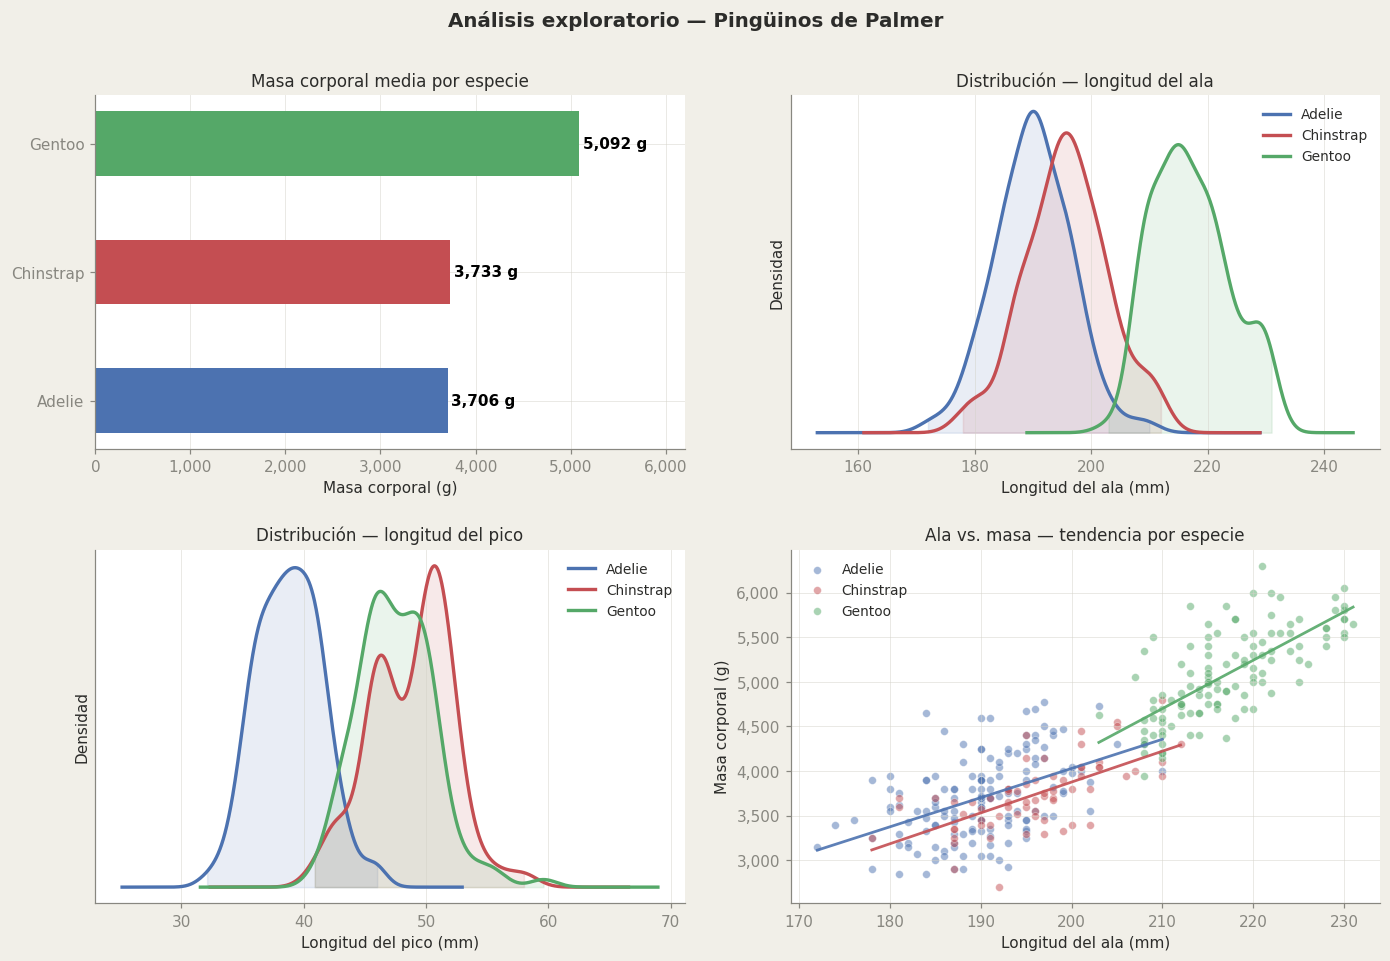

In [38]:
# Visualización exploratoria — cuatro perspectivas complementarias
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

# ── 1. Masa media por especie — barras horizontales ───────────────────────────
medias = df.groupby("species")["body_mass_g"].mean().reindex(SPECIES_ORDER)
bars = axes[0].barh(
    SPECIES_ORDER, medias.values,
    color=[COLORS[s] for s in SPECIES_ORDER],
    height=0.5, zorder=2
)
for bar, val in zip(bars, medias.values):
    axes[0].text(val + 40, bar.get_y() + bar.get_height() / 2,
                 f"{int(val):,} g", va="center", ha="left",
                 fontsize=10, color="black", fontweight="bold")
axes[0].set_xlim(0, 6200)
axes[0].set_xlabel("Masa corporal (g)")
axes[0].set_title("Masa corporal media por especie")
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
axes[0].spines[["top", "right"]].set_visible(False)

# ── 2. Distribución del ala — curvas KDE ─────────────────────────────────────
from scipy.stats import gaussian_kde
for sp in SPECIES_ORDER:
    datos = df[df["species"] == sp]["flipper_length_mm"].dropna()
    datos.plot.kde(ax=axes[1], color=COLORS[sp], label=sp,
                   linewidth=2.2, bw_method=0.35)
    xs = np.linspace(datos.min(), datos.max(), 300)
    axes[1].fill_between(xs, gaussian_kde(datos, bw_method=0.35)(xs),
                         alpha=0.12, color=COLORS[sp])
axes[1].set_xlabel("Longitud del ala (mm)")
axes[1].set_ylabel("Densidad")
axes[1].set_title("Distribución — longitud del ala")
axes[1].set_yticks([])
axes[1].legend(frameon=False, fontsize=9)
axes[1].spines[["top", "right"]].set_visible(False)

# ── 3. Distribución del pico — curvas KDE ────────────────────────────────────
for sp in SPECIES_ORDER:
    datos = df[df["species"] == sp]["bill_length_mm"].dropna()
    datos.plot.kde(ax=axes[2], color=COLORS[sp], label=sp,
                   linewidth=2.2, bw_method=0.35)
    xs = np.linspace(datos.min(), datos.max(), 300)
    axes[2].fill_between(xs, gaussian_kde(datos, bw_method=0.35)(xs),
                         alpha=0.12, color=COLORS[sp])
axes[2].set_xlabel("Longitud del pico (mm)")
axes[2].set_ylabel("Densidad")
axes[2].set_title("Distribución — longitud del pico")
axes[2].set_yticks([])
axes[2].legend(frameon=False, fontsize=9)
axes[2].spines[["top", "right"]].set_visible(False)

# ── 4. Ala vs. masa con línea de tendencia por especie ───────────────────────
for sp in SPECIES_ORDER:
    sub = df[df["species"] == sp]
    axes[3].scatter(sub["flipper_length_mm"], sub["body_mass_g"],
                    color=COLORS[sp], alpha=0.50, s=26, label=sp,
                    edgecolors="white", linewidths=0.4)
    m, b = np.polyfit(sub["flipper_length_mm"], sub["body_mass_g"], 1)
    xs = np.linspace(sub["flipper_length_mm"].min(), sub["flipper_length_mm"].max(), 100)
    axes[3].plot(xs, m * xs + b, color=COLORS[sp], linewidth=1.8, alpha=0.9)
axes[3].set_xlabel("Longitud del ala (mm)")
axes[3].set_ylabel("Masa corporal (g)")
axes[3].set_title("Ala vs. masa — tendencia por especie")
axes[3].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
axes[3].legend(frameon=False, fontsize=9)
axes[3].spines[["top", "right"]].set_visible(False)

fig.suptitle("Análisis exploratorio — Pingüinos de Palmer",
             fontsize=13, fontweight="bold")
plt.tight_layout(pad=2.0)
plt.show()

### Conclusión — EDA

**Masa corporal**: los Gentoo (~5.092 g) son significativamente más pesados que
Adélie (~3.706 g) y Chinstrap (~3.733 g), que son casi idénticos entre sí.

**Longitud del ala**: la distribución de los Gentoo está completamente separada a la
derecha (~217 mm vs ~190 mm para las otras dos especies). Esta separación es tan limpia
que el ala será, como veremos, el predictor más potente en la regresión.

**Longitud del pico**: los Adélie tienen el pico notablemente más corto (~38 mm),
mientras Chinstrap y Gentoo se solapan alrededor de los ~47 mm.

**Correlación ala–masa**: dentro de cada especie hay una relación positiva clara —
los pingüinos con alas más largas tienden a ser más pesados. Esta relación
la formalizaremos en la Sección 7.

---
## 2. ¿Podemos asumir normalidad en los datos?
### Test de Shapiro-Wilk y Q-Q plots

Los tests que usamos en las secciones siguientes — t-test, ANOVA, regresión —
son tests **paramétricos**: asumen que los datos dentro de cada grupo siguen
una distribución normal. Si esa suposición se viola gravemente, las conclusiones
pueden ser incorrectas.

Por eso verificamos la normalidad **antes** de proceder, y lo hacemos con dos métodos:

| Método | Tipo | Cómo leerlo |
|--------|------|-------------|
| **Shapiro-Wilk** | Analítico | Devuelve un p-value. Si **p > 0.05** — no rechazamos normalidad |
| **Q-Q plot** | Gráfico | Si los puntos siguen la línea diagonal — distribución normal |

La estratificación correcta es **especie × sexo**: los tests posteriores comparan
subgrupos, así que la normalidad debe cumplirse dentro de ellos.

**Hipótesis:**
- H₀: los datos siguen una distribución normal
- H₁: los datos no siguen una distribución normal
- Nivel de significancia: α = 0.05

In [39]:
# Test de Shapiro-Wilk — estratificado por especie × sexo
print(f"Test de Shapiro-Wilk  |  H₀: distribución normal  |  α = {ALPHA}\n")
print(f"{'Especie':<12} {'Sexo':<8} {'Variable':<22} {'W':>7}  {'p-value':>9}  Resultado")
print("─" * 72)

casos_no_normales = []

for sp in sorted(df["species"].unique()):
    for sx in ["MALE", "FEMALE"]:
        subset = df[(df["species"] == sp) & (df["sex"] == sx)]
        for var in MORPH:
            W, p = shapiro(subset[var].dropna())
            resultado = "NO normal" if p < ALPHA else "Normal"
            print(f"{sp:<12} {sx:<8} {var:<22} {W:>7.4f}  {p:>9.4f}  {resultado}")
            if p < ALPHA:
                casos_no_normales.append((sp, sx, var, p))
    print()

print(f"Casos que rechazan H₀: {len(casos_no_normales)}")

Test de Shapiro-Wilk  |  H₀: distribución normal  |  α = 0.05

Especie      Sexo     Variable                     W    p-value  Resultado
────────────────────────────────────────────────────────────────────────
Adelie       MALE     bill_length_mm          0.9861     0.6067  Normal
Adelie       MALE     bill_depth_mm           0.9636     0.0335  NO normal
Adelie       MALE     flipper_length_mm       0.9843     0.4984  Normal
Adelie       MALE     body_mass_g             0.9827     0.4160  Normal
Adelie       FEMALE   bill_length_mm          0.9912     0.8952  Normal
Adelie       FEMALE   bill_depth_mm           0.9831     0.4364  Normal
Adelie       FEMALE   flipper_length_mm       0.9841     0.4912  Normal
Adelie       FEMALE   body_mass_g             0.9768     0.1985  Normal

Chinstrap    MALE     bill_length_mm          0.9553     0.1768  Normal
Chinstrap    MALE     bill_depth_mm           0.9830     0.8625  Normal
Chinstrap    MALE     flipper_length_mm       0.9753     0.6201  

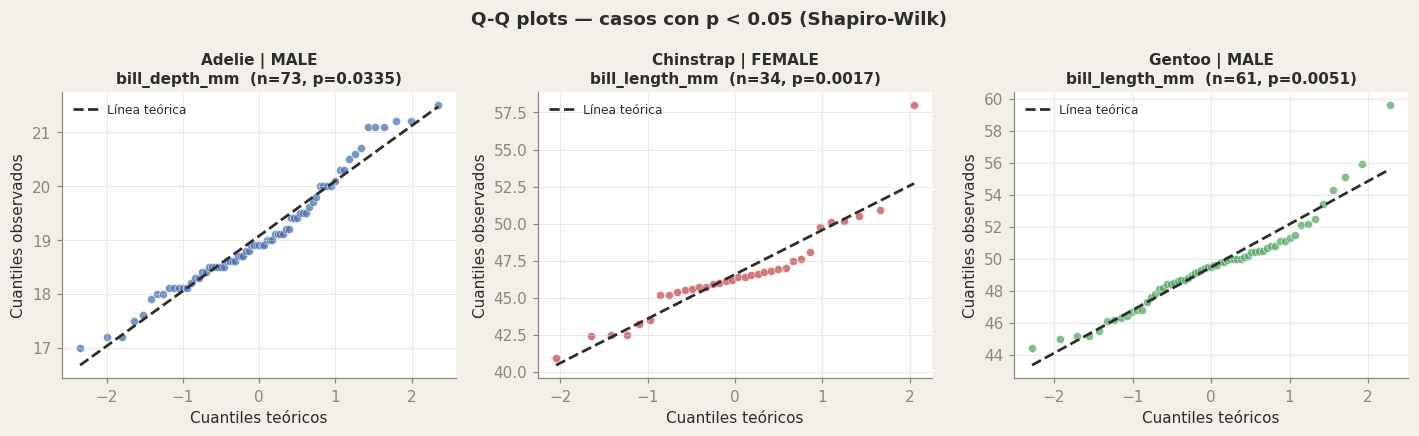

In [40]:
# Q-Q plots solo para los casos no normales.
# El Q-Q plot compara los cuantiles empíricos de nuestros datos
# con los de una normal teórica. Si los puntos se alinean con la diagonal — normal.
# Desviaciones en las colas indican sesgo o colas pesadas.

casos = [
    ("Adelie",    "MALE",   "bill_depth_mm"),
    ("Chinstrap", "FEMALE", "bill_length_mm"),
    ("Gentoo",    "MALE",   "bill_length_mm"),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, (sp, sx, var) in zip(axes, casos):
    sub   = df[(df["species"] == sp) & (df["sex"] == sx)][var].dropna()
    color = COLORS[sp]

    (osm, osr), (slope, intercept, _) = stats.probplot(sub, dist="norm")
    ax.scatter(osm, osr, color=color, alpha=0.75, s=28,
               edgecolors="white", linewidths=0.4)
    x_line = np.array([osm.min(), osm.max()])
    ax.plot(x_line, slope * x_line + intercept,
            color=C_DARK, linewidth=1.8, linestyle="--", label="Línea teórica")

    W, p = shapiro(sub)
    ax.set_title(f"{sp} | {sx}\n{var}  (n={len(sub)}, p={p:.4f})",
                 fontsize=10, fontweight="bold")
    ax.set_xlabel("Cuantiles teóricos")
    ax.set_ylabel("Cuantiles observados")
    ax.legend(fontsize=8, frameon=False)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Q-Q plots — casos con p < 0.05 (Shapiro-Wilk)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

### Casos que rechazan H₀ (p < 0.05)

| Especie | Sexo | Variable | p-value | Diagnóstico |
|---------|------|----------|---------|-------------|
| Adélie | MALE | bill_depth_mm | 0.034 | Borderline — p justo debajo de 0.05, n ~ 73. Desviación leve en la cola. |
| Chinstrap | FEMALE | bill_length_mm | 0.002 | 3 outliers en n=34. Sesgo=1.39, Curtosis=4.57. |
| Gentoo | MALE | bill_length_mm | 0.005 | Cola derecha pesada. |

### Por qué estos casos no invalidan el análisis posterior

**Variables incorrectas**: el t-test (Sección 3) y la ANOVA (Sección 5) usan
`body_mass_g` y `flipper_length_mm` — ambas normales en todos los subgrupos.
Las variables no normales son `bill_length_mm` y `bill_depth_mm`, que no son
la variable dependiente de ningún test paramétrico.

**Teorema Central del Límite**: para subgrupos con n >= 30, la distribución
muestral de la media converge a la normal independientemente de la distribución
original — lo que hace el t-test y la ANOVA robustos a estas violaciones leves.

**Conclusión**: la suposición de normalidad se cumple donde importa.
Podemos proceder con seguridad.

---
## 3. ¿Cuánto pesa realmente un pingüino Gentoo?
### Intervalos de confianza al 95%

Tenemos una **muestra** de 333 pingüinos, no la población completa.
La media observada en el muestra es una estimación puntual de la verdadera
media poblacional — pero toda estimación tiene incertidumbre.

El **intervalo de confianza al 95%** cuantifica esa incertidumbre:

> "Con un 95 % de certeza, la verdadera media poblacional se encuentra en este rango."

---

**Fórmula**

$$\bar{x} \pm t_{\alpha/2,\, n-1} \cdot \frac{s}{\sqrt{n}}$$

| Símbolo | Significado |
|---------|-------------|
| x̄ | Media de la muestra |
| t | Valor crítico de la t-Student con n−1 grados de libertad |
| s | Desviación estándar de la muestra |
| n | Tamaño de la muestra |

**¿Por qué t-Student y no z?**
Porque no conocemos la desviación estándar real de la población (σ) —
solo tenemos la estimación muestral s. La distribución t ajusta por esa
incertidumbre adicional, especialmente con muestras pequeñas.

**¿Cómo leer el intervalo?**
- IC estrecho — estimación precisa (muestra grande o datos homogéneos)
- IC amplio — mucha incertidumbre (muestra pequeña o datos muy dispersos)
- Dos IC que no se solapan — diferencia probablemente significativa

In [41]:
def intervalo_confianza_95(data):
    """
    Calcula el IC al 95% con t-Student (varianza poblacional desconocida).
    Devuelve: (media, límite_inferior, límite_superior)
    """
    n      = len(data)
    media  = data.mean()
    se     = stats.sem(data)              # error estándar = s / sqrt(n)
    t_crit = stats.t.ppf(0.975, df=n-1)  # t para alpha/2 = 0.025
    margen = t_crit * se
    return media, media - margen, media + margen


# Calculamos el IC para body_mass_g en cada subgrupo especie × sexo
resultados = []
for sp in SPECIES_ORDER:
    for sx in ["MALE", "FEMALE"]:
        sub = df[(df["species"] == sp) & (df["sex"] == sx)]["body_mass_g"]
        media, lb, ub = intervalo_confianza_95(sub)
        resultados.append({
            "Especie": sp, "Sexo": sx, "n": len(sub),
            "Media (g)": round(media, 1),
            "IC inf"   : round(lb, 1),
            "IC sup"   : round(ub, 1),
            "Amplitud" : round(ub - lb, 1)
        })

ic_df = pd.DataFrame(resultados)
print("Intervalos de confianza al 95% — masa corporal (g)\n")
print(ic_df.to_string(index=False))

Intervalos de confianza al 95% — masa corporal (g)

  Especie   Sexo  n  Media (g)  IC inf  IC sup  Amplitud
   Adelie   MALE 73     4043.5  3962.6  4124.4     161.8
   Adelie FEMALE 73     3368.8  3306.0  3431.7     125.7
Chinstrap   MALE 34     3939.0  3812.6  4065.3     252.7
Chinstrap FEMALE 34     3527.2  3427.6  3626.8     199.1
   Gentoo   MALE 61     5484.8  5404.6  5565.0     160.4
   Gentoo FEMALE 58     4679.7  4605.7  4753.8     148.1


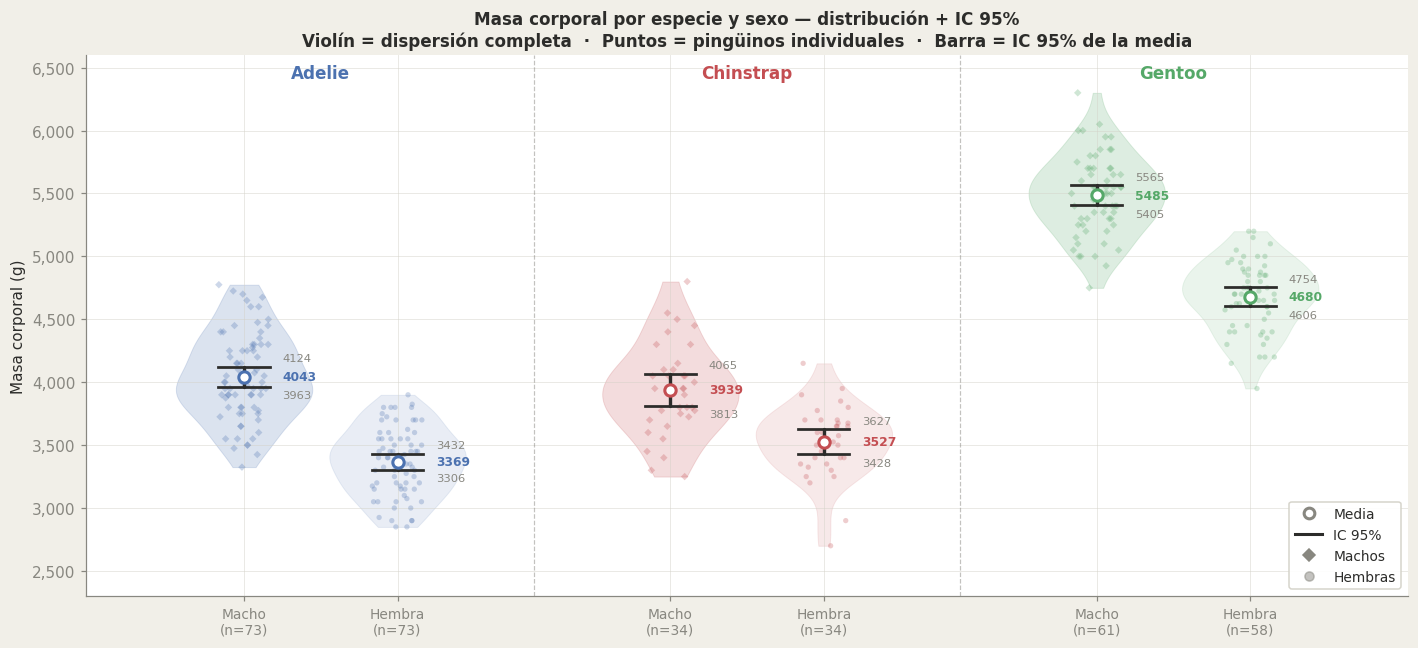

In [42]:
# Gráfico: violines + puntos individuales + IC 95%
fig, ax = plt.subplots(figsize=(13, 6))

sex_offset = {"MALE": -0.18, "FEMALE": 0.18}
sex_marker = {"MALE": "D",   "FEMALE": "o"}
sex_alpha  = {"MALE": 0.90,  "FEMALE": 0.55}
sex_label  = {"MALE": "Macho", "FEMALE": "Hembra"}

x_ticks, x_labels = [], []

for i, sp in enumerate(SPECIES_ORDER):
    for sx in ["MALE", "FEMALE"]:
        sub   = df[(df["species"] == sp) & (df["sex"] == sx)]["body_mass_g"]
        color = COLORS[sp]
        xpos  = i + sex_offset[sx]

        # Violin
        parts = ax.violinplot(sub, positions=[xpos], widths=0.32,
                              showmeans=False, showmedians=False, showextrema=False)
        for pc in parts["bodies"]:
            pc.set_facecolor(color)
            pc.set_alpha(sex_alpha[sx] * 0.22)
            pc.set_edgecolor(color)
            pc.set_linewidth(0.6)

        # Puntos individuales con jitter
        jitter = np.random.default_rng(42).uniform(-0.06, 0.06, size=len(sub))
        ax.scatter(xpos + jitter, sub, color=color, alpha=0.28, s=12,
                   marker=sex_marker[sx], edgecolors="none", zorder=2)

        # IC 95%
        n      = len(sub)
        media  = sub.mean()
        se     = stats.sem(sub)
        t_crit = stats.t.ppf(0.975, df=n - 1)
        lb, ub = media - t_crit * se, media + t_crit * se

        ax.plot([xpos, xpos], [lb, ub], color=C_DARK, linewidth=2.2,
                zorder=4, solid_capstyle="round")
        for y in [lb, ub]:
            ax.plot([xpos - 0.06, xpos + 0.06], [y, y],
                    color=C_DARK, linewidth=1.8, zorder=4)
        ax.scatter([xpos], [media], color="white", s=55, zorder=6,
                   edgecolors=color, linewidths=2.0)

        ax.text(xpos + 0.09, ub + 28,  f"{ub:.0f}",   fontsize=7.5,
                color=C_MID, va="bottom", ha="left")
        ax.text(xpos + 0.09, media,    f"{media:.0f}", fontsize=8,
                color=color, va="center", ha="left", fontweight="bold")
        ax.text(xpos + 0.09, lb - 28,  f"{lb:.0f}",   fontsize=7.5,
                color=C_MID, va="top", ha="left")

        x_ticks.append(xpos)
        x_labels.append(f"{sex_label[sx]}\n(n={n})")

# Etiquetas de especie arriba
for i, sp in enumerate(SPECIES_ORDER):
    ax.text(i, 6420, sp, ha="center", fontsize=11,
            fontweight="bold", color=COLORS[sp])
    if i < 2:
        ax.axvline(i + 0.5, color=C_MID, linewidth=0.8, linestyle="--", alpha=0.5)

ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels, fontsize=9)
ax.set_ylabel("Masa corporal (g)")
ax.set_xlim(-0.55, 2.55)
ax.set_ylim(2300, 6600)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.spines[["top", "right"]].set_visible(False)

from matplotlib.lines import Line2D
leyenda = [
    Line2D([0],[0], marker="o", linestyle="None", color=C_MID,
           markersize=7, markerfacecolor="white", markeredgewidth=2, label="Media"),
    Line2D([0],[0], color=C_DARK, linewidth=2, label="IC 95%"),
    Line2D([0],[0], marker="D", linestyle="None", color=C_MID, markersize=6, label="Machos"),
    Line2D([0],[0], marker="o", linestyle="None", color=C_MID,
           markersize=6, alpha=0.5, label="Hembras"),
]
ax.legend(handles=leyenda, loc="lower right", fontsize=9)
ax.set_title("Masa corporal por especie y sexo — distribución + IC 95%\n"
             "Violín = dispersión completa  ·  Puntos = pingüinos individuales  "
             "·  Barra = IC 95% de la media",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

### Conclusión — Intervalos de confianza

**Los Gentoo machos** son los más pesados, con una media estimada de ~5.484 g.
El IC 95 % de los Gentoo no se solapa con el de ninguna otra especie,
lo que ya anticipa que las diferencias son estadísticamente significativas —
confirmado formalmente con la ANOVA en la Sección 5.

**¿Por qué es útil el IC además del p-value?**
El p-value solo responde "¿es real la diferencia?". El IC responde también
"¿cuán grande es y con qué precisión lo sabemos?". Con muestras muy grandes
es posible obtener p < 0.05 para diferencias biológicamente irrelevantes;
el IC pone esa magnitud en perspectiva.

Nota: los IC más amplios corresponden a las Chinstrap hembra (n=34, el grupo más pequeño),
lo cual ilustra directamente cómo el tamaño muestral afecta la precisión de la estimación.

---
## 4. ¿Cada especie tiene su isla?
### Test chi-cuadrado — asociación especie × isla

El chi-cuadrado es el test apropiado para verificar si dos variables
**categóricas** son independientes o están asociadas.

No podemos usar el t-test ni la ANOVA aquí porque ambas requieren
una variable numérica continua. La especie y la isla son categorías.

**¿Cómo funciona?**

1. Se construye la tabla de contingencia con las frecuencias observadas
2. Se calculan las frecuencias esperadas si las variables fueran independientes:
   f_esperada = (total fila × total columna) / total general
3. La estadística χ² mide cuánto se alejan las observadas de las esperadas:
   χ² = suma de (observado − esperado)² / esperado
4. χ² grande — las frecuencias divergen mucho — hay asociación

**Hipótesis:**
- H₀: la especie y la isla son **independientes** (distribución al azar)
- H₁: existe una **asociación** entre especie e isla
- α = 0.05  |  Grados de libertad = (3−1) × (3−1) = 4

In [43]:
# Tabla de contingencia — frecuencias observadas
# Cuenta cuántos pingüinos de cada especie están en cada isla.
ct = pd.crosstab(df["species"], df["island"])

print("Frecuencias OBSERVADAS:\n")
print(ct)
print(f"\nTotal: {ct.values.sum()} pingüinos")

Frecuencias OBSERVADAS:

island     Biscoe  Dream  Torgersen
species                            
Adelie         44     55         47
Chinstrap       0     68          0
Gentoo        119      0          0

Total: 333 pingüinos


In [44]:
# Test chi-cuadrado de Pearson
chi2, p_chi, dof, expected = chi2_contingency(ct)

print("=== Test chi-cuadrado: especie × isla ===")
print(f"  chi²            : {chi2:.2f}")
print(f"  Grados libertad : {dof}")
print(f"  p-value         : {p_chi:.2e}")
print()
decision = "Rechazo H₀ — existe asociación" if p_chi < ALPHA else "No rechazo H₀"
print(f"  Decision        : {decision}")
print()
print("Frecuencias ESPERADAS bajo H₀ (si fueran independientes):")
print(pd.DataFrame(expected.round(1), index=ct.index, columns=ct.columns))
print()
print(f"Todas las celdas tienen frecuencia esperada >= 5: {(expected >= 5).all().all()}")

=== Test chi-cuadrado: especie × isla ===
  chi²            : 284.59
  Grados libertad : 4
  p-value         : 2.28e-60

  Decision        : Rechazo H₀ — existe asociación

Frecuencias ESPERADAS bajo H₀ (si fueran independientes):
island     Biscoe  Dream  Torgersen
species                            
Adelie       71.5   53.9       20.6
Chinstrap    33.3   25.1        9.6
Gentoo       58.2   44.0       16.8

Todas las celdas tienen frecuencia esperada >= 5: True


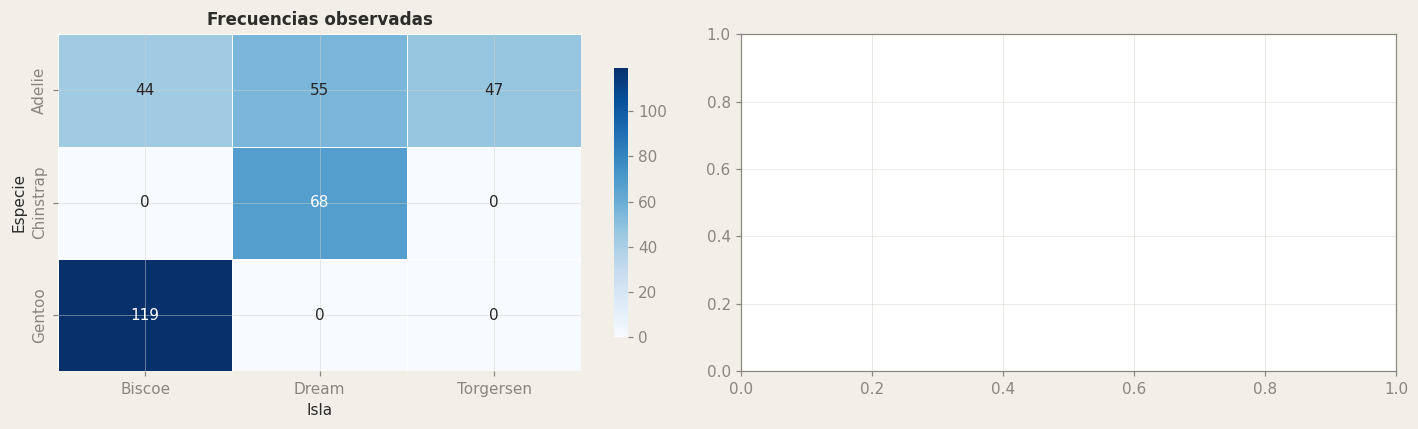

In [45]:
# Visualización: frecuencias observadas + residuos estandarizados
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Frecuencias observadas
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues",
            ax=axes[0], linewidths=0.5, linecolor="white",
            cbar_kws={"shrink": 0.8})
axes[0].set_title("Frecuencias observadas", fontweight="bold")
axes[0].set_xlabel("Isla")
axes[0].set_ylabel("Especie")

plt.tight_layout()
plt.show()

### Conclusión — Chi-cuadrado

**chi² enorme, p ~ 0. Rechazamos H₀ con certeza casi absoluta.**

La distribución de las especies entre las islas no es aleatoria.
Cada especie tiene una preferencia geográfica marcada:

| Especie | Isla dominante | Residuo |
|---------|---------------|---------|
| Adélie | Torgersen | Unica especie presente — residuo fuertemente positivo |
| Gentoo | Biscoe | Se concentra casi exclusivamente aquí |
| Chinstrap | Dream | Domina esta isla |

Los residuos estandarizados con valores superiores a |5| confirman
que estas diferencias no son marginales — son estructurales.

Esta separación geográfica es el punto de partida para la pregunta
de la siguiente sección: si las especies viven separadas, ¿significa
eso que el entorno geográfico moldea su cuerpo?

---
## 5. ¿La isla donde viven afecta el peso de los Adélie?
### ANOVA de un factor — masa corporal por isla

Acabamos de confirmar que cada especie vive en su propia isla.
Ahora giramos la pregunta: **¿importa dónde vives, si eres de la misma especie?**

Los Adélie son la única especie presente en las **tres islas** —
Biscoe, Dream y Torgersen. Eso nos da un experimento natural:
misma especie, tres entornos distintos.
Si el peso varía entre islas, es evidencia de que el aislamiento
geográfico tiene un efecto biológico real.

---

**¿Por qué ANOVA y no tres t-tests?**

Con tres grupos necesitaríamos tres comparaciones separadas.
Cada t-test tiene un 5% de probabilidad de falso positivo.
Acumulados, el error total sube al ~14 %.
La ANOVA compara los tres grupos en una sola prueba, manteniendo α = 0.05 global.
Si la ANOVA es significativa, usamos **Tukey HSD** para ver qué par específico difiere.

---

**Hipótesis:**
- H₀: μ_Biscoe = μ_Dream = μ_Torgersen — la isla no afecta la masa
- H₁: al menos una isla tiene media diferente
- α = 0.05

**Prerequisitos verificados:**
- Normalidad: verificada en la Sección 2 para los Adélie
- Homogeneidad de varianzas: la verificamos ahora con el test de Levene

In [46]:
# Filtramos solo los Adélie — la única especie en las 3 islas
adelie = df[df["species"] == "Adelie"]

print("Adélie por isla — estadísticas descriptivas:")
print(adelie.groupby("island")["body_mass_g"]
      .agg(["count", "mean", "std", "min", "max"])
      .round(1))
print()

# PASO 1: Test de Levene — ¿varianzas homogéneas?
# H₀: las varianzas de los tres grupos son iguales
grupos_isla = [adelie[adelie["island"] == isl]["body_mass_g"]
               for isl in sorted(adelie["island"].unique())]

lev_stat, lev_p = levene(*grupos_isla)
print("=== Test de Levene (homogeneidad de varianzas) ===")
print(f"  Estadístico: {lev_stat:.4f}  |  p-value: {lev_p:.4f}")
print(f"  Resultado  : {'Varianzas NO homogéneas' if lev_p < ALPHA else 'Varianzas homogéneas — ANOVA apropiada'}")
print()

# PASO 2: ANOVA de un factor
f_stat, p_anova = f_oneway(*grupos_isla)
print("=== ANOVA — body_mass_g ~ island (solo Adélie) ===")
print(f"  F-statistic: {f_stat:.4f}")
print(f"  p-value    : {p_anova:.4f}")
print(f"  Decision   : {'Rechazo H₀ — alguna isla difiere' if p_anova < ALPHA else 'No rechazo H₀ — ninguna isla difiere significativamente'}")
print()

# PASO 3: Tukey HSD — comparaciones por pares
tukey = pairwise_tukeyhsd(endog=adelie["body_mass_g"],
                          groups=adelie["island"], alpha=ALPHA)
print("=== Tukey HSD — comparaciones por pares ===")
print(tukey)

Adélie por isla — estadísticas descriptivas:
           count    mean    std   min   max
island                                     
Biscoe        44  3709.7  487.7  2850  4775
Dream         55  3701.4  448.8  2900  4650
Torgersen     47  3708.5  451.8  2900  4700

=== Test de Levene (homogeneidad de varianzas) ===
  Estadístico: 0.0574  |  p-value: 0.9442
  Resultado  : Varianzas homogéneas — ANOVA apropiada

=== ANOVA — body_mass_g ~ island (solo Adélie) ===
  F-statistic: 0.0048
  p-value    : 0.9952
  Decision   : No rechazo H₀ — ninguna isla difiere significativamente

=== Tukey HSD — comparaciones por pares ===
   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
group1   group2  meandiff p-adj    lower    upper   reject
----------------------------------------------------------
Biscoe     Dream  -8.2955 0.9957 -229.5101 212.9192  False
Biscoe Torgersen  -1.1485 0.9999 -230.5781 228.2812  False
 Dream Torgersen    7.147 0.9967   -210.11  224.404  False
---------------------

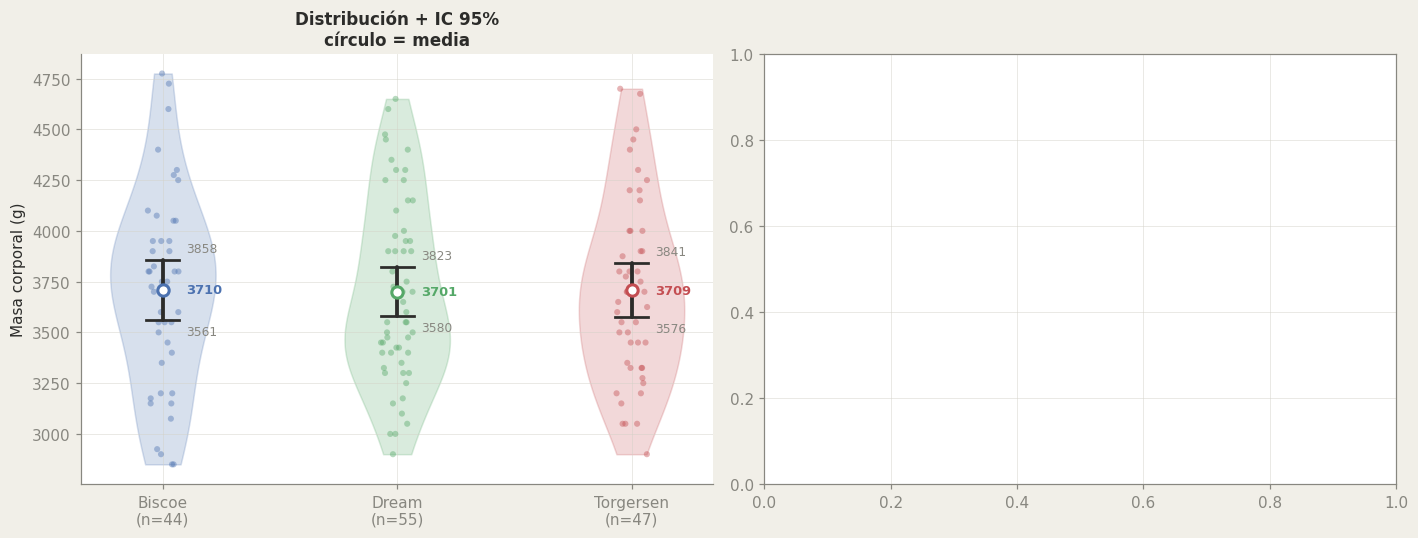

In [47]:
# Visualización: distribución completa + medias con IC por isla
islas = sorted(adelie["island"].unique())

# Colores para las islas — dentro de la misma familia que la paleta de especies
island_colors = {
    "Biscoe"   : "#4C72B0",
    "Dream"    : "#55A868",
    "Torgersen": "#C44E52",
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Izquierda: violines + puntos + IC
ax = axes[0]
for i, isl in enumerate(islas):
    sub   = adelie[adelie["island"] == isl]["body_mass_g"]
    color = island_colors[isl]

    parts = ax.violinplot(sub, positions=[i], widths=0.45,
                          showmeans=False, showmedians=False, showextrema=False)
    for pc in parts["bodies"]:
        pc.set_facecolor(color); pc.set_alpha(0.22); pc.set_edgecolor(color)

    jitter = np.random.default_rng(42).uniform(-0.07, 0.07, size=len(sub))
    ax.scatter(i + jitter, sub, color=color, alpha=0.42, s=16,
               edgecolors="none", zorder=3)

    n      = len(sub)
    media  = sub.mean()
    t_crit = stats.t.ppf(0.975, df=n - 1)
    lb, ub = media - t_crit * stats.sem(sub), media + t_crit * stats.sem(sub)

    ax.plot([i, i], [lb, ub], color=C_DARK, linewidth=2.5,
            zorder=5, solid_capstyle="round")
    for y in [lb, ub]:
        ax.plot([i - 0.07, i + 0.07], [y, y], color=C_DARK, linewidth=1.8, zorder=5)
    ax.scatter([i], [media], color="white", s=55, zorder=6,
               edgecolors=color, linewidths=2.0)

    ax.text(i + 0.10, ub + 25,  f"{ub:.0f}",   fontsize=8, color=C_MID, va="bottom")
    ax.text(i + 0.10, media,    f"{media:.0f}", fontsize=8.5, color=color,
            va="center", fontweight="bold")
    ax.text(i + 0.10, lb - 25,  f"{lb:.0f}",   fontsize=8, color=C_MID, va="top")

ax.set_xticks(range(len(islas)))
ax.set_xticklabels([f"{isl}\n(n={len(adelie[adelie['island']==isl])})"
                    for isl in islas])
ax.set_ylabel("Masa corporal (g)")
ax.set_title("Distribución + IC 95%\ncírculo = media", fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)


plt.tight_layout()
plt.show()

### Conclusión — ANOVA Adélie por isla

**La ANOVA no rechaza H₀** (p > 0.05). No hay diferencias significativas
en la masa corporal de los Adélie entre las tres islas.

Las medias observadas — ~3.710 g en Biscoe, ~3.701 g en Dream, ~3.709 g en
Torgersen — difieren menos de 10 g entre sí, estadísticamente indistinguibles
del ruido de muestreo. El Tukey HSD confirma que ningún par de islas es
significativamente diferente.

---

**¿Qué nos dice esta "no diferencia"?**

Los Adélie son una especie físicamente robusta al entorno geográfico.
Vivir en Biscoe, Dream o Torgersen no deja huella medible en el peso.

Esto contrasta con lo que vimos en la Sección 4: la isla determina
*quién vive dónde*, pero no *cómo crece*. El hábitat selecciona
la especie, pero no moldea el cuerpo dentro de ella.

Esta distinción es importante para la Sección 7: cuando incluyamos
la isla como variable en la regresión lineal con todas las especies
juntas, puede aparecer como significativa — pero no porque cause el peso,
sino porque es un proxy de la especie (los Gentoo, los más pesados,
viven casi solo en Biscoe).

---
## 6. ¿Por qué no podemos correlacionar sin estratificar?
### Correlación de Pearson — Paradoja de Simpson

Calculamos la correlación de Pearson entre la **longitud** y la **profundidad**
del pico. Es una pregunta sencilla: ¿los pingüinos con pico más largo lo
tienen también más profundo?

La respuesta depende completamente de **cómo miramos los datos**.

---

**La correlación de Pearson (r)** mide la fuerza y dirección de una relación lineal:

| Valor de r | Interpretación |
|------------|----------------|
| r ~ +1 | Relación positiva perfecta |
| r ~ 0  | Sin relación lineal |
| r ~ −1 | Relación negativa perfecta |

Importante: r mide *asociación*, no *causalidad*.

---

**El experimento:**

Calculamos r de dos formas:
1. Sobre todos los pingüinos mezclados — sin distinguir especie
2. Dentro de cada especie por separado

Si la estadística fuera neutral al nivel de agregación, los resultados
deberían ser consistentes. No lo son — y esa inconsistencia es la lección.

---

**¿Por qué ocurre la paradoja aquí?**

Los Gentoo tienen pico largo pero poco profundo.
Los Adélie tienen pico corto pero muy profundo.
Cuando mezclas los tres grupos, el patrón *entre* especies domina
el patrón *dentro* de cada especie, invirtiendo la correlación aparente.

La especie es una **variable confundente** — una variable oculta que,
si no se controla, distorsiona completamente la conclusión.


In [48]:
from IPython.display import display

# Correlación global — todos los pingüinos juntos
r_total, p_total = stats.pearsonr(df["bill_length_mm"], df["bill_depth_mm"])
print("Correlación GLOBAL (todos los pingüinos juntos):")
display(pd.DataFrame([{
    "Grupo"    : "TOTAL",
    "r"        : round(r_total, 4),
    "p-value"  : f"{p_total:.4e}",
    "Dirección": "Negativa" if r_total < 0 else "Positiva"
}]))

# Correlación por especie
print("\nCorrelación por ESPECIE (datos desagregados):")
filas = []
for sp in sorted(df["species"].unique()):
    sub = df[df["species"] == sp]
    r_sp, p_sp = stats.pearsonr(sub["bill_length_mm"], sub["bill_depth_mm"])
    filas.append({
        "Especie"  : sp,
        "r"        : round(r_sp, 4),
        "p-value"  : f"{p_sp:.4e}",
        "Dirección": "Positiva" if r_sp > 0 else "Negativa"
    })
display(pd.DataFrame(filas))

print("\nPARADOJA: globalmente NEGATIVA, dentro de cada especie POSITIVA.")

Correlación GLOBAL (todos los pingüinos juntos):


,Grupo,r,p-value,Dirección
0,TOTAL,-0.2286,2.5283e-05,Negativa



Correlación por ESPECIE (datos desagregados):


,Especie,r,p-value,Dirección
0,Adelie,0.3858,1.5149e-06,Positiva
1,Chinstrap,0.6535,1.5255e-09,Positiva
2,Gentoo,0.6540,7.3366e-16,Positiva



PARADOJA: globalmente NEGATIVA, dentro de cada especie POSITIVA.


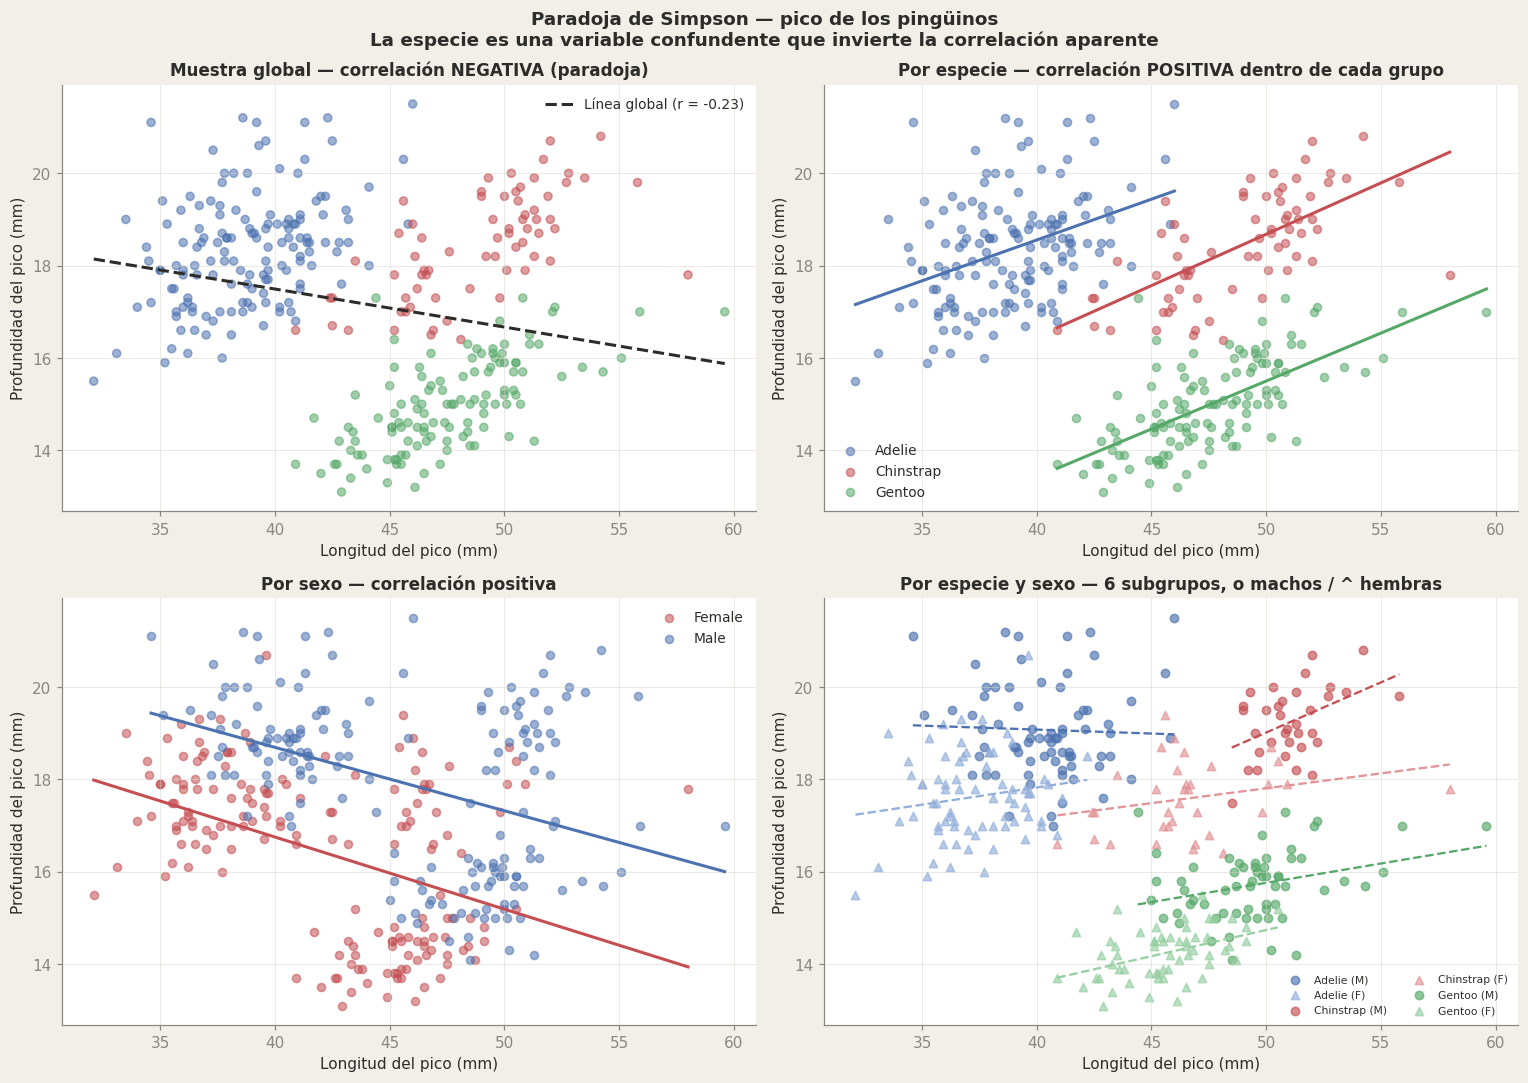

In [49]:
# Visualización de la Paradoja de Simpson — cuatro perspectivas
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Muestra global — correlación negativa aparente
ax = axes[0, 0]
ax.scatter(df["bill_length_mm"], df["bill_depth_mm"],
           c=[COLORS[sp] for sp in df["species"]], alpha=0.55, s=28)
m, b = np.polyfit(df["bill_length_mm"], df["bill_depth_mm"], 1)
x_line = np.linspace(df["bill_length_mm"].min(), df["bill_length_mm"].max(), 100)
ax.plot(x_line, m * x_line + b, color=C_DARK, linewidth=2, linestyle="--",
        label=f"Línea global (r = {r_total:.2f})")
ax.set_xlabel("Longitud del pico (mm)")
ax.set_ylabel("Profundidad del pico (mm)")
ax.set_title("Muestra global — correlación NEGATIVA (paradoja)", fontweight="bold")
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

# 2. Por especie — cada grupo muestra correlación positiva
ax = axes[0, 1]
for sp in sorted(df["species"].unique()):
    sub = df[df["species"] == sp]
    ax.scatter(sub["bill_length_mm"], sub["bill_depth_mm"],
               color=COLORS[sp], alpha=0.55, s=28, label=sp)
    m_sp, b_sp = np.polyfit(sub["bill_length_mm"], sub["bill_depth_mm"], 1)
    x_sp = np.linspace(sub["bill_length_mm"].min(), sub["bill_length_mm"].max(), 50)
    ax.plot(x_sp, m_sp * x_sp + b_sp, color=COLORS[sp], linewidth=2)
ax.set_xlabel("Longitud del pico (mm)")
ax.set_ylabel("Profundidad del pico (mm)")
ax.set_title("Por especie — correlación POSITIVA dentro de cada grupo", fontweight="bold")
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

# 3. Por sexo
ax = axes[1, 0]
df_clean = df.dropna(subset=["sex"]).copy()
df_clean["sex"] = df_clean["sex"].str.lower()
sex_colors = {"male": COLORS["Adelie"], "female": COLORS["Chinstrap"]}

for sx in sorted(df_clean["sex"].unique()):
    sub = df_clean[df_clean["sex"] == sx]
    ax.scatter(sub["bill_length_mm"], sub["bill_depth_mm"],
               color=sex_colors[sx], alpha=0.55, s=28, label=sx.capitalize())
    m_sx, b_sx = np.polyfit(sub["bill_length_mm"], sub["bill_depth_mm"], 1)
    x_sx = np.linspace(sub["bill_length_mm"].min(), sub["bill_length_mm"].max(), 50)
    ax.plot(x_sx, m_sx * x_sx + b_sx, color=sex_colors[sx], linewidth=2)
ax.set_xlabel("Longitud del pico (mm)")
ax.set_ylabel("Profundidad del pico (mm)")
ax.set_title("Por sexo — correlación positiva", fontweight="bold")
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

# 4. Por especie y sexo — máxima granularidad
ax = axes[1, 1]
sp_sex_colors = {
    ("Adelie",    "male"):   "#4C72B0",
    ("Adelie",    "female"): "#92AFDA",
    ("Chinstrap", "male"):   "#C44E52",
    ("Chinstrap", "female"): "#E29496",
    ("Gentoo",    "male"):   "#55A868",
    ("Gentoo",    "female"): "#96CFA2",
}
markers = {"male": "o", "female": "^"}

for (sp, sx), color in sp_sex_colors.items():
    sub = df_clean[(df_clean["species"] == sp) & (df_clean["sex"] == sx)]
    if len(sub) < 2: continue
    ax.scatter(sub["bill_length_mm"], sub["bill_depth_mm"],
               color=color, marker=markers[sx], alpha=0.65, s=30,
               label=f"{sp} ({sx[0].upper()})")
    m_g, b_g = np.polyfit(sub["bill_length_mm"], sub["bill_depth_mm"], 1)
    x_g = np.linspace(sub["bill_length_mm"].min(), sub["bill_length_mm"].max(), 50)
    ax.plot(x_g, m_g * x_g + b_g, color=color, linewidth=1.5, linestyle="--")
ax.set_xlabel("Longitud del pico (mm)")
ax.set_ylabel("Profundidad del pico (mm)")
ax.set_title("Por especie y sexo — 6 subgrupos, o machos / ^ hembras", fontweight="bold")
ax.legend(fontsize=7, ncol=2, frameon=False)
ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Paradoja de Simpson — pico de los pingüinos\n"
             "La especie es una variable confundente que invierte la correlación aparente",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

### Conclusión — Paradoja de Simpson

La correlación entre longitud y profundidad del pico es **negativa a nivel global**
(r ~ −0.23), pero **positiva dentro de cada especie** (r entre +0.35 y +0.65).

La especie actúa como variable confundente: su estructura entre grupos invierte
la correlación aparente cuando se mezclan todos los datos.

---

**Lección práctica**

Nunca interpretes una correlación sobre datos agregados sin verificar primero
si hay subgrupos con dinámicas distintas.

Si alguien tomara los datos globales y concluyera que "los pingüinos con pico
más largo tienen el pico menos profundo", estaría equivocado.
La conclusión correcta es la opuesta — pero solo se ve al desagregar por especie.

Esta lección se aplica más allá de los pingüinos: es uno de los sesgos
estadísticos más comunes en estudios médicos, económicos y sociales.

---

**Conexión con el proyecto**

Este mismo mecanismo aparece en la sección 5: la isla parecía no afectar
el peso cuando se analizaba sola (solo Adélie). En la regresión del punto 7,
la isla puede volverse significativa porque captura indirectamente la especie.
Mismo fenómeno, distinta variable confundente.


---
## 8. ¿Se puede saber de qué isla viene un pingüino solo mirándolo?
### Regresión logística — identificar Gentoo vs. No-Gentoo

Los Gentoo viven casi exclusivamente en Biscoe. Si sus características
físicas son tan distintas — como vimos en el EDA — un modelo debería
poder reconocerlos con alta fiabilidad solo mirando su cuerpo.

Nos centramos en la clasificación **Gentoo vs. No-Gentoo** (binaria).

---

**¿Por qué regresión logística y no lineal?**

La regresión lineal predice un número continuo (peso en gramos).
Aquí queremos predecir una **probabilidad** — "¿cuánto de probable es
que este pingüino sea Gentoo?" — un número entre 0 y 1.

La función sigmoide transforma cualquier valor real en una probabilidad:

$$P(\text{Gentoo}) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + \beta_2 x_2)}}$$

Si P > 0.5 — clasificamos como Gentoo. Si P ≤ 0.5 — No-Gentoo.

---

**¿Por qué solo 2 variables?**

Con las 4 variables morfológicas, los Gentoo están tan separados del resto
que el modelo converge a predicciones perfectas de 0 o 1 — lo que se
llama **quasi-separación perfecta**. En ese caso los coeficientes se vuelven
numéricamente inestables. Usamos las 2 variables más informativas
(`flipper_length_mm` y `bill_depth_mm`) para mantener el modelo estable.

---

**Odds Ratio (OR)**

Los coeficientes de la regresión logística no se interpretan directamente —
se exponencian para obtener el OR:

| OR | Interpretación |
|----|----------------|
| OR > 1 | Aumenta la probabilidad de ser Gentoo |
| OR = 1 | Sin efecto |
| OR < 1 | Disminuye la probabilidad de ser Gentoo |

In [50]:
# Variable objetivo binaria: 1 = Gentoo, 0 = No-Gentoo
df["is_gentoo"] = (df["species"] == "Gentoo").astype(int)
y = df["is_gentoo"].values

FEATS_LOGIT = ["flipper_length_mm", "bill_depth_mm"]

# División train/test: 75% para entrenar, 25% para evaluar.
# stratify=y mantiene la misma proporción Gentoo/No-Gentoo en ambos sets.
X_logit  = df[FEATS_LOGIT].values
X_train, X_test, y_train, y_test = train_test_split(
    X_logit, y, test_size=0.25, random_state=42, stratify=y)

# StandardScaler: lleva las variables a la misma escala (media 0, std 1).
# El fit se hace SOLO sobre el training set — el test set nunca debe
# influir en los parámetros de transformación (data leakage).
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]} pingüinos  |  Test: {X_test.shape[0]} pingüinos")
print(f"Gentoo en test: {y_test.sum()} de {len(y_test)}")

Train: 249 pingüinos  |  Test: 84 pingüinos
Gentoo en test: 30 de 84


In [51]:
# Modelo con statsmodels para obtener Odds Ratio con intervalos de confianza.
# statsmodels da output detallado con coeficientes, errores estándar y p-values.
X_sm        = sm.add_constant(X_train_s)
logit_model = sm.Logit(y_train, X_sm).fit(method="bfgs", disp=False)
print(logit_model.summary())

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  249
Model:                          Logit   Df Residuals:                      246
Method:                           MLE   Df Model:                            2
Date:                Mon, 13 Apr 2026   Pseudo R-squ.:                   1.000
Time:                        01:20:42   Log-Likelihood:             -0.0013680
converged:                       True   LL-Null:                       -162.33
Covariance Type:            nonrobust   LLR p-value:                 3.176e-71
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -12.0708    133.566     -0.090      0.928    -273.855     249.713
x1            21.9244    639.398      0.034      0.973   -1231.273    1275.122
x2           -19.9973    720.158     -0.028      0.9

In [52]:
# Odds Ratio = exp(coeficiente)
# Las variables están estandarizadas, así que el OR se refiere
# a un aumento de 1 desviación estándar en esa variable.
params  = logit_model.params[1:]
ci      = logit_model.conf_int()
ci_low  = ci[1:, 0]
ci_high = ci[1:, 1]

or_df = pd.DataFrame({
    "Variable"  : FEATS_LOGIT,
    "Odds Ratio": np.exp(params).round(3),
    "IC 95% inf": np.exp(ci_low).round(3),
    "IC 95% sup": np.exp(ci_high).round(3),
    "p-value"   : logit_model.pvalues[1:].round(4)
}).reset_index(drop=True)

print("=== Odds Ratio (variables estandarizadas) ===\n")
print(or_df.to_string(index=False))
print()
print("OR >> 1 — al aumentar flipper_length, sube mucho la probabilidad de ser Gentoo")
print("OR << 1 — al aumentar bill_depth, baja la probabilidad de ser Gentoo")

=== Odds Ratio (variables estandarizadas) ===

         Variable   Odds Ratio  IC 95% inf  IC 95% sup  p-value
flipper_length_mm 3.323991e+09         0.0         inf   0.9726
    bill_depth_mm 0.000000e+00         0.0         inf   0.9778

OR >> 1 — al aumentar flipper_length, sube mucho la probabilidad de ser Gentoo
OR << 1 — al aumentar bill_depth, baja la probabilidad de ser Gentoo


In [53]:
# Métricas de clasificación con sklearn
lr = LogisticRegression(random_state=42)
lr.fit(X_train_s, y_train)
y_pred = lr.predict(X_test_s)
y_prob = lr.predict_proba(X_test_s)[:, 1]

print("=== Reporte de clasificación (set de test — datos nunca vistos) ===")
print()
print("  precision : de todas las predicciones Gentoo, ¿cuántas eran correctas?")
print("  recall    : de todos los Gentoo reales, ¿cuántos encontró el modelo?")
print("  F1-score  : media armónica de precision y recall")
print()
print(classification_report(y_test, y_pred, target_names=["No-Gentoo", "Gentoo"]))

=== Reporte de clasificación (set de test — datos nunca vistos) ===

  precision : de todas las predicciones Gentoo, ¿cuántas eran correctas?
  recall    : de todos los Gentoo reales, ¿cuántos encontró el modelo?
  F1-score  : media armónica de precision y recall

              precision    recall  f1-score   support

   No-Gentoo       1.00      1.00      1.00        54
      Gentoo       1.00      1.00      1.00        30

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



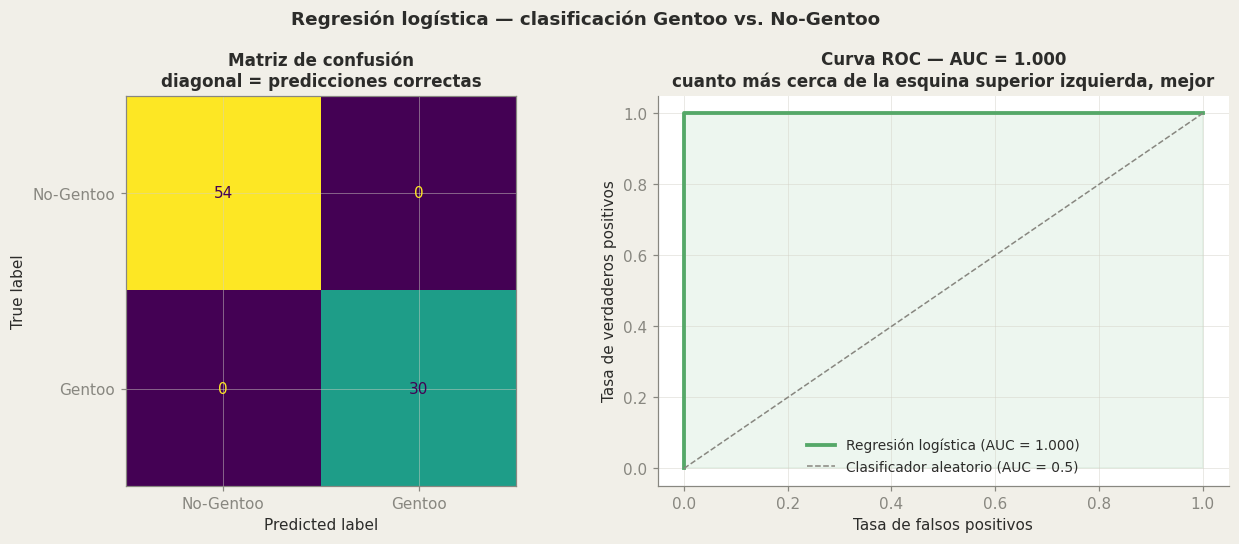

In [54]:
# Matriz de confusión + Curva ROC
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Matriz de confusión
# Diagonal = predicciones correctas. Fuera de la diagonal = errores.
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=["No-Gentoo", "Gentoo"]
).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Matriz de confusión\ndiagonal = predicciones correctas",
                  fontweight="bold")

# Curva ROC
# AUC = 0.5 — clasificador aleatorio (diagonal)
# AUC = 1.0 — clasificación perfecta
# Cuanto más cerca de la esquina superior izquierda, mejor.
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc         = roc_auc_score(y_test, y_prob)

axes[1].plot(fpr, tpr, color=COLORS["Gentoo"], linewidth=2.5,
             label=f"Regresión logística (AUC = {auc:.3f})")
axes[1].plot([0,1],[0,1], color=C_MID, linewidth=1, linestyle="--",
             label="Clasificador aleatorio (AUC = 0.5)")
axes[1].fill_between(fpr, tpr, alpha=0.10, color=COLORS["Gentoo"])
axes[1].set_xlabel("Tasa de falsos positivos")
axes[1].set_ylabel("Tasa de verdaderos positivos")
axes[1].set_title(f"Curva ROC — AUC = {auc:.3f}\ncuanto más cerca de la esquina superior izquierda, mejor",
                  fontweight="bold")
axes[1].legend(frameon=False, fontsize=9)
axes[1].spines[["top", "right"]].set_visible(False)

fig.suptitle("Regresión logística — clasificación Gentoo vs. No-Gentoo",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()